##  Imports and Device Setup

In [1]:
# [CELL 1] Imports and Setup
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Set device to GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(30)
np.random.seed(30)

Using device: cuda


## Custom Dataset Class

In [2]:
# [CELL 2] Custom Dataset Definition
class CASIAIntervalDataset(Dataset):
    def __init__(self, image_paths, labels, class_to_idx, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label_str = self.labels[idx]

        # Load image. CASIA images are grayscale, but ResNet expects 3 channels (RGB)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label_idx = self.class_to_idx[label_str]
        return image, label_idx

def parse_casia_dataset(data_dir):
    """Scans the directory and extracts paths and labels."""
    image_paths = []
    labels = []

    # Iterate through subject folders (001, 002, etc.)
    for subject in sorted(os.listdir(data_dir)):
        subject_path = os.path.join(data_dir, subject)
        if not os.path.isdir(subject_path):
            continue

        # Iterate through Left (L) and Right (R) eye folders
        for side in ['L', 'R']:
            side_path = os.path.join(subject_path, side)
            if not os.path.isdir(side_path):
                continue

            # Treat each eye as a unique identity (e.g., "001_L")
            class_name = f"{subject}_{side}"

            for img_name in os.listdir(side_path):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    image_paths.append(os.path.join(side_path, img_name))
                    labels.append(class_name)

    # Create mapping from class name to integer index
    unique_classes = sorted(list(set(labels)))
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(unique_classes)}

    return image_paths, labels, class_to_idx

In [3]:
# [NEW CELL B] Smart Training Loop (Saves the Best Model Automatically)
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=15):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # --- TRAINING PHASE ---
        model.train()
        running_loss, running_corrects = 0.0, 0

        for inputs, labels in tqdm(train_loader, desc="Training"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = running_corrects.double() / len(train_dataset)
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, val_corrects = 0.0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        epoch_val_loss = val_loss / len(val_dataset)
        epoch_val_acc = val_corrects.double() / len(val_dataset)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc.item())

        print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        print(f'Val Loss:   {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}\n')

        # deep copy the model if it's the best one we've seen so far
        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            print(f"🌟 New best model found! Accuracy: {best_acc:.4f}")

    print(f'Training complete. Best Validation Accuracy: {best_acc:.4f}')

    # Load best model weights before returning
    model.load_state_dict(best_model_wts)
    return model, history

## Preprocessing, Splitting, and DataLoaders

In [4]:
# [CELL 3] Data Loading, Filtering, and Augmentation
from collections import Counter

DATA_DIR = r"C:\Users\afara\PycharmProjects\Deep_learning_iris-recognition\Data\CASIA-Iris-Interval"

# 1. Parse the dataset
image_paths, labels, _ = parse_casia_dataset(DATA_DIR)

# 2. FILTER OUT CLASSES WITH ONLY 1 IMAGE
# Count how many images each eye has
label_counts = Counter(labels)

# Keep only labels that have 2 or more images
valid_labels = {label for label, count in label_counts.items() if count >= 2}

filtered_image_paths = []
filtered_labels = []

for path, label in zip(image_paths, labels):
    if label in valid_labels:
        filtered_image_paths.append(path)
        filtered_labels.append(label)

# Re-create the class-to-index dictionary with the filtered data
unique_classes = sorted(list(set(filtered_labels)))
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(unique_classes)}
num_classes = len(class_to_idx)

print(f"Original Dataset: {len(image_paths)} images, {len(set(labels))} unique eyes.")
print(f"Filtered Dataset: {len(filtered_image_paths)} images, {num_classes} unique eyes (Removed eyes with < 2 images).")

# 3. Train/Validation Split (80/20) - Stratified
X_train, X_val, y_train, y_val = train_test_split(
    filtered_image_paths, filtered_labels, test_size=0.2, random_state=42, stratify=filtered_labels
)

# 4. Define Transformations
# Training: Resize, mild augmentation, tensor conversion, ImageNet normalization
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10), # Slight tilt for robustness
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation: Only resize and normalize (NO augmentation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 5. Create Datasets and DataLoaders
train_dataset = CASIAIntervalDataset(X_train, y_train, class_to_idx, transform=train_transform)
val_dataset = CASIAIntervalDataset(X_val, y_val, class_to_idx, transform=val_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Training batches: {len(train_loader)} | Validation batches: {len(val_loader)}")

Original Dataset: 2639 images, 395 unique eyes.
Filtered Dataset: 2616 images, 372 unique eyes (Removed eyes with < 2 images).
Training batches: 66 | Validation batches: 17


In [5]:
# [NEW CELL A] Load and Combine Multiple Datasets
from collections import Counter
import copy

# Define both dataset directories
DIR_INTERVAL = r"C:\Users\afara\PycharmProjects\Deep_learning_iris-recognition\Data\CASIA-Iris-Interval"
DIR_LAMP = r"C:\Users\afara\PycharmProjects\Deep_learning_iris-recognition\Data\CASIA-Iris-Lamp"

DATA_DIRS = [DIR_INTERVAL, DIR_LAMP]

def parse_multiple_casia_datasets(data_dirs):
    image_paths = []
    labels = []

    for data_dir in data_dirs:
        for subject in sorted(os.listdir(data_dir)):
            subject_path = os.path.join(data_dir, subject)
            if not os.path.isdir(subject_path): continue

            for side in ['L', 'R']:
                side_path = os.path.join(subject_path, side)
                if not os.path.isdir(side_path): continue

                class_name = f"{subject}_{side}" # e.g., "001_L"

                for img_name in os.listdir(side_path):
                    if img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                        image_paths.append(os.path.join(side_path, img_name))
                        labels.append(class_name)

    return image_paths, labels

# 1. Parse all directories
image_paths, labels = parse_multiple_casia_datasets(DATA_DIRS)

# 2. Filter out classes with < 2 images
label_counts = Counter(labels)
valid_labels = {label for label, count in label_counts.items() if count >= 2}

filtered_paths = []
filtered_labels = []
for path, label in zip(image_paths, labels):
    if label in valid_labels:
        filtered_paths.append(path)
        filtered_labels.append(label)

unique_classes = sorted(list(set(filtered_labels)))
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(unique_classes)}
num_classes = len(class_to_idx)

print(f"Combined Dataset: {len(filtered_paths)} images across {num_classes} unique eyes.")

# 3. Train/Validation Split (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    filtered_paths, filtered_labels, test_size=0.2, random_state=42, stratify=filtered_labels
)

# 4. Datasets and Loaders (Reusing train_transform and val_transform from earlier)
train_dataset = CASIAIntervalDataset(X_train, y_train, class_to_idx, transform=train_transform)
val_dataset = CASIAIntervalDataset(X_val, y_val, class_to_idx, transform=val_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Training batches: {len(train_loader)} | Validation batches: {len(val_loader)}")

Combined Dataset: 18851 images across 820 unique eyes.
Training batches: 472 | Validation batches: 118


## Visualizing the Preprocessed Data

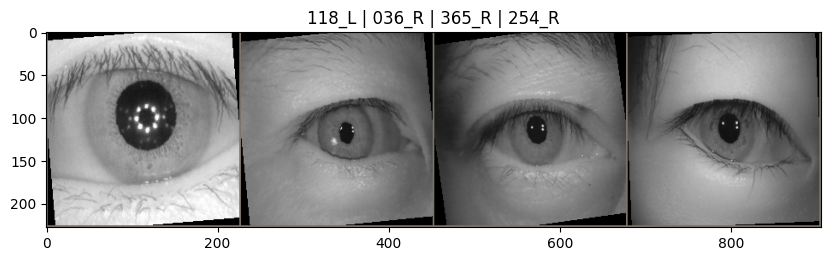

In [6]:
# [CELL 4] Visualize a batch of images
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    # Un-normalize for displaying
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

# Get a batch of training data
inputs, classes = next(iter(train_loader))

# Plot the first 4 images
import torchvision
out = torchvision.utils.make_grid(inputs[:4])
# Create reverse dictionary to get string labels
idx_to_class = {v: k for k, v in class_to_idx.items()}
titles = [idx_to_class[x.item()] for x in classes[:4]]

plt.figure(figsize=(10, 5))
imshow(out, title=" | ".join(titles))

## Initialize ResNet-50 and Transfer Learning

In [7]:
# [CELL 5] Load ResNet-50
# Load pre-trained ResNet-50
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Phase 1: Freeze all base layers (Optional but recommended for start)
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer
# model.fc.in_features is usually 2048 for ResNet-50
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.4), # Added regularization
    nn.Linear(num_ftrs, num_classes)
) # requires_grad is True by default for newly created layers

model = model.to(device)

# Define Loss and Optimizer (Only optimizing the new FC layer)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print(f"Model initialized. Output classes: {num_classes}")

Model initialized. Output classes: 820


## Training and Validation Functions

In [8]:
# [CELL 6] Training Loop Function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # --- TRAINING PHASE ---
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in tqdm(train_loader, desc="Training"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad() # Clear gradients

            # Forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = running_corrects.double() / len(train_dataset)
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())

        # --- VALIDATION PHASE ---
        model.eval() # Set to evaluation mode (disables dropout, affects BatchNorm)
        val_loss = 0.0
        val_corrects = 0

        with torch.no_grad(): # Disable gradient calculation for speed and memory
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        epoch_val_loss = val_loss / len(val_dataset)
        epoch_val_acc = val_corrects.double() / len(val_dataset)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc.item())

        print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        print(f'Val Loss:   {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}\n')

    return model, history

## Execute Training

Epoch 1/10
----------


Training: 100%|██████████| 472/472 [01:35<00:00,  4.96it/s]


Train Loss: 6.0424 Acc: 0.0801
Val Loss:   3.9284 Acc: 0.3450

Epoch 2/10
----------


Training: 100%|██████████| 472/472 [01:29<00:00,  5.30it/s]


Train Loss: 3.2765 Acc: 0.4226
Val Loss:   2.1305 Acc: 0.6805

Epoch 3/10
----------


...

Train Loss: 0.8726 Acc: 0.8146
Val Loss:   0.6602 Acc: 0.8722

Epoch 9/10
----------


Training: 100%|██████████| 472/472 [01:29<00:00,  5.30it/s]


Train Loss: 0.8093 Acc: 0.8211
Val Loss:   0.6390 Acc: 0.8711

Epoch 10/10
----------


Training: 100%|██████████| 472/472 [01:27<00:00,  5.42it/s]


Train Loss: 0.7604 Acc: 0.8253
Val Loss:   0.6080 Acc: 0.8722



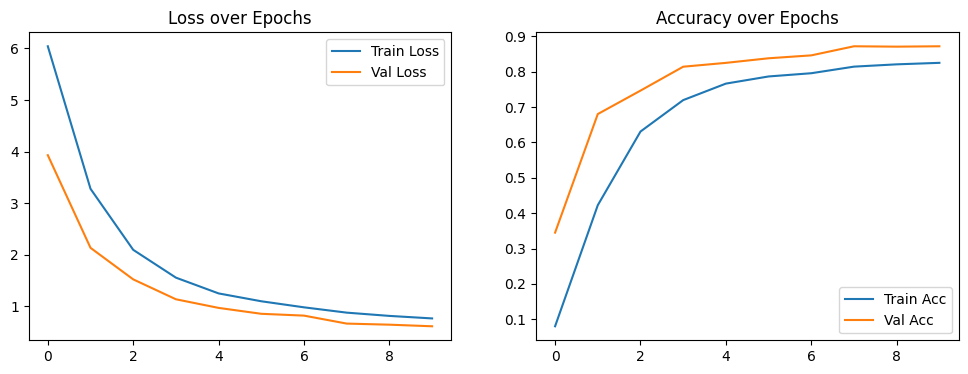

In [9]:
# [CELL 7] Run Training
EPOCHS = 10

trained_model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=EPOCHS
)

# Plot the results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.legend()
plt.show()

## unfreezing

In [10]:
# [CELL 8] Phase 2 Fine-Tuning
print("Unfreezing layers for fine-tuning...")
for param in model.parameters():
    param.requires_grad = True # Unfreeze everything

# Create a new optimizer with a MUCH smaller learning rate!
optimizer_ft = optim.Adam(model.parameters(), lr=1e-5)

# Train for another 5-10 epochs
model, history_ft = train_model(model, train_loader, val_loader, criterion, optimizer_ft, num_epochs=10)

Unfreezing layers for fine-tuning...
Epoch 1/10
----------


Training: 100%|██████████| 472/472 [02:29<00:00,  3.16it/s]


Train Loss: 0.3177 Acc: 0.9273
Val Loss:   0.2115 Acc: 0.9578

Epoch 2/10
----------


Training: 100%|██████████| 472/472 [02:44<00:00,  2.87it/s]


Train Loss: 0.1366 Acc: 0.9702
Val Loss:   0.1445 Acc: 0.9730

Epoch 3/10
----------


...

Train Loss: 0.0200 Acc: 0.9959
Val Loss:   0.0784 Acc: 0.9891

Epoch 9/10
----------


Training: 100%|██████████| 472/472 [02:19<00:00,  3.39it/s]


Train Loss: 0.0159 Acc: 0.9971
Val Loss:   0.0781 Acc: 0.9889

Epoch 10/10
----------


Training: 100%|██████████| 472/472 [02:18<00:00,  3.40it/s]


Train Loss: 0.0149 Acc: 0.9973
Val Loss:   0.0739 Acc: 0.9899



## Model saving

In [11]:
# [CELL 9] Save the best model
import torch

# Save only the model weights (recommended standard practice)
save_path = 'resnet50_casia_iris_97_9.pth'
torch.save(model.state_dict(), save_path)
print(f"Model successfully saved to {save_path}")

Model successfully saved to resnet50_casia_iris_97_9.pth


## Visualizing

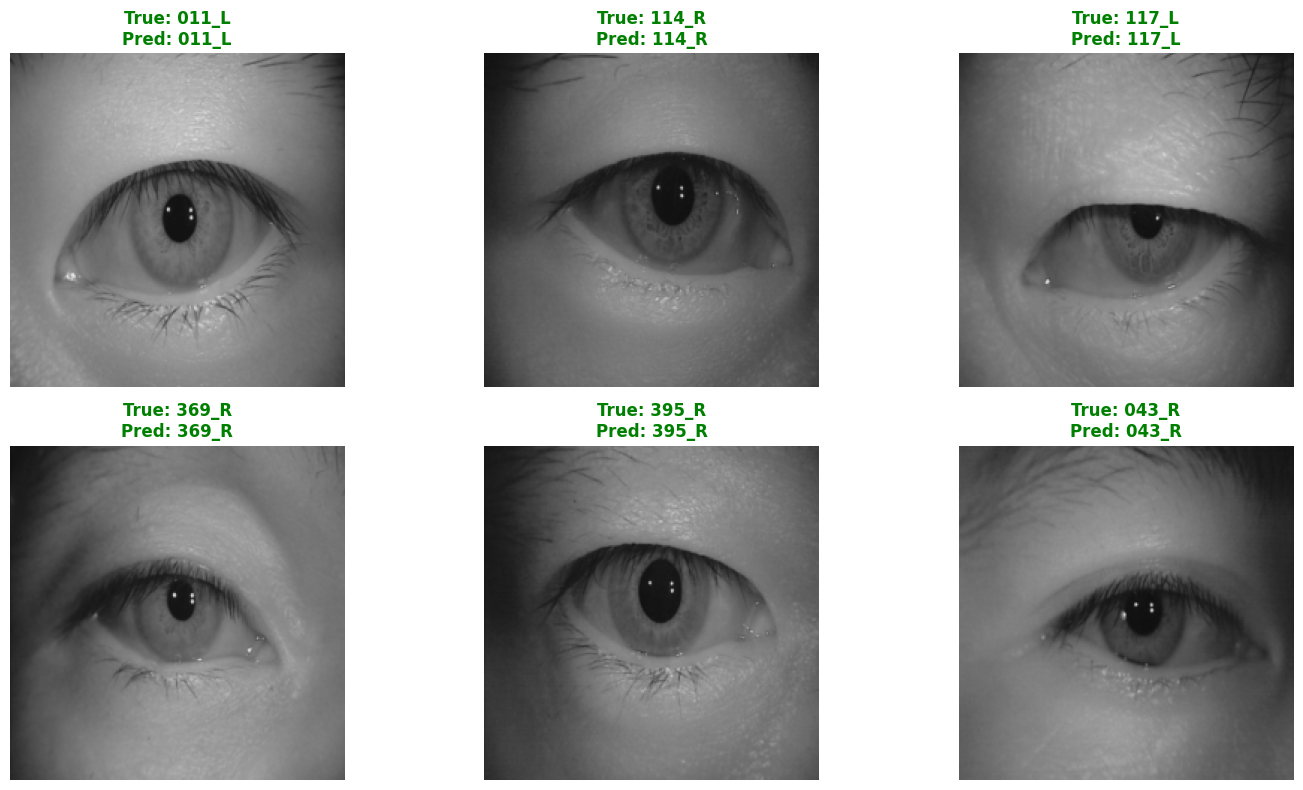

In [12]:
# [CELL 10] Visualize Predictions
import torchvision

def visualize_predictions(model, dataloader, class_to_idx, num_images=6):
    model.eval()

    # Get a batch of validation data
    inputs, labels = next(iter(dataloader))
    inputs = inputs.to(device)
    labels = labels.to(device)

    # Make predictions
    with torch.no_grad():
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

    # Move to CPU for plotting
    inputs = inputs.cpu()
    preds = preds.cpu()
    labels = labels.cpu()

    # Reverse the class dictionary to get the actual names (e.g., "001_L")
    idx_to_class = {v: k for k, v in class_to_idx.items()}

    plt.figure(figsize=(15, 8))
    for i in range(num_images):
        plt.subplot(2, 3, i+1)

        # Un-normalize image for viewing
        img = inputs[i].numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        plt.imshow(img)

        actual_class = idx_to_class[labels[i].item()]
        pred_class = idx_to_class[preds[i].item()]

        color = 'green' if preds[i] == labels[i] else 'red'
        plt.title(f"True: {actual_class}\nPred: {pred_class}", color=color, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_predictions(model, val_loader, class_to_idx, num_images=6)

# EffecientNET

In [13]:
# [NEW CELL C] Initialize and Train EfficientNet-B0

# 1. Initialize Model
eff_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Phase 1: Freeze base layers
for param in eff_model.parameters():
    param.requires_grad = False

num_ftrs = eff_model.classifier[1].in_features
eff_model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(num_ftrs, num_classes)
)
eff_model = eff_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_eff = optim.Adam(eff_model.classifier.parameters(), lr=0.001)

# ==========================================
# PHASE 1: Train Classification Head
# ==========================================
print("--- PHASE 1: Training Head Only ---")
eff_model, history_1 = train_model(
    model=eff_model, train_loader=train_loader, val_loader=val_loader,
    criterion=criterion, optimizer=optimizer_eff, num_epochs=10
)

# ==========================================
# PHASE 2: Fine-Tune Entire Network
# ==========================================
print("\n--- PHASE 2: Fine-Tuning Entire Network ---")
for param in eff_model.parameters():
    param.requires_grad = True

# VERY small learning rate for fine-tuning!
optimizer_eff_ft = optim.Adam(eff_model.parameters(), lr=1e-5)

# Set to 20 epochs. The "Smart" loop will save the best one automatically.
eff_model, history_2 = train_model(
    model=eff_model, train_loader=train_loader, val_loader=val_loader,
    criterion=criterion, optimizer=optimizer_eff_ft, num_epochs=20
)

# Save the absolute best weights to disk
torch.save(eff_model.state_dict(), 'efficientnet_b0_combined_best.pth')
print("Model saved to disk!")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\afara/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:05<00:00, 3.76MB/s]


--- PHASE 1: Training Head Only ---
Epoch 1/10
----------


Training: 100%|██████████| 472/472 [01:15<00:00,  6.21it/s]


Train Loss: 4.9267 Acc: 0.3440
Val Loss:   2.5355 Acc: 0.7926

Epoch 2/10
----------


...

Train Loss: 0.0195 Acc: 0.9967
Val Loss:   0.0664 Acc: 0.9915

Epoch 19/20
----------


Training: 100%|██████████| 472/472 [01:39<00:00,  4.75it/s]


Train Loss: 0.0191 Acc: 0.9968
Val Loss:   0.0669 Acc: 0.9912

Epoch 20/20
----------


Training: 100%|██████████| 472/472 [01:38<00:00,  4.78it/s]


Train Loss: 0.0165 Acc: 0.9979
Val Loss:   0.0672 Acc: 0.9912

Model saved to disk!


# Testing and validation

In [14]:
# [NEW CELL D] Advanced Testing & Evaluation Metrics
import torch
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from torchvision import models
import torch.nn as nn
from tqdm import tqdm

# 1. Re-initialize the model architecture to match the saved weights
print("Loading saved EfficientNet-B0 model for testing...")
test_model = models.efficientnet_b0(weights=None) # No need to download ImageNet weights again
num_ftrs = test_model.classifier[1].in_features
test_model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(num_ftrs, num_classes)
)

# Load your best saved weights (Change filename if testing ResNet instead)
test_model.load_state_dict(torch.load('efficientnet_b0_combined_best.pth'))
test_model = test_model.to(device)
test_model.eval()

# 2. Lists to store predictions and true labels
all_preds = []
all_labels = []
top5_correct = 0
total_samples = 0

print("Running inference on Test/Validation set...")
with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc="Testing"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = test_model(inputs)

        # Get Top-1 predictions
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Get Top-5 predictions
        _, top5_preds = outputs.topk(5, 1, True, True)
        top5_preds = top5_preds.t()
        correct = top5_preds.eq(labels.view(1, -1).expand_as(top5_preds))
        top5_correct += correct[:5].reshape(-1).float().sum(0, keepdim=True).item()
        total_samples += labels.size(0)

# 3. Calculate Advanced Metrics
top1_acc = accuracy_score(all_labels, all_preds) * 100
top5_acc = (top5_correct / total_samples) * 100

# Average='macro' calculates metrics for each class independently and averages them
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)

print("\n" + "="*40)
print("🏆 ADVANCED TESTING RESULTS (820 Classes)")
print("="*40)
print(f"Top-1 Accuracy : {top1_acc:.2f}%")
print(f"Top-5 Accuracy : {top5_acc:.2f}%")
print(f"Macro Precision: {precision * 100:.2f}%")
print(f"Macro Recall   : {recall * 100:.2f}%")
print(f"Macro F1-Score : {f1 * 100:.2f}%")
print("="*40)

Loading saved EfficientNet-B0 model for testing...
Running inference on Test/Validation set...


Testing: 100%|██████████| 118/118 [00:24<00:00,  4.82it/s]


🏆 ADVANCED TESTING RESULTS (820 Classes)
Top-1 Accuracy : 99.12%
Top-5 Accuracy : 99.60%
Macro Precision: 99.32%
Macro Recall   : 99.13%
Macro F1-Score : 99.12%


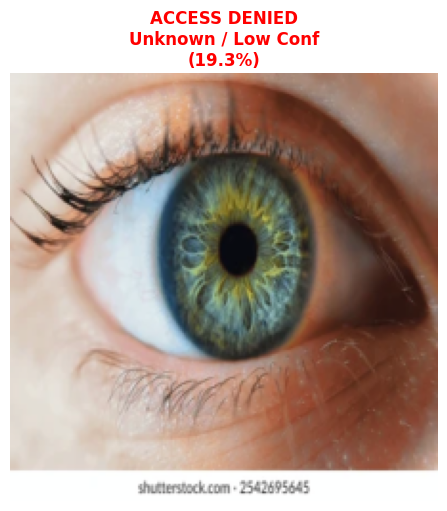

In [16]:
# [NEW CELL D] Real-World Inference on New Unseen Data
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import os
import numpy as np

# 1. Configuration
# Create this folder and put some new images inside it!
TEST_DIR = r"C:\Users\afara\PycharmProjects\Deep_learning_iris-recognition\Data\Test_Images"
MODEL_WEIGHTS = 'efficientnet_b0_combined_best.pth'
CONFIDENCE_THRESHOLD = 0.60 # 60% confidence required to "Unlock"

# 2. Rebuild the Model Architecture (EfficientNet-B0)
# Note: num_classes must be exactly 820 (or whatever your combined dataset had)
test_model = models.efficientnet_b0(weights=None)
num_ftrs = test_model.classifier[1].in_features
test_model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(num_ftrs, num_classes) # Uses num_classes from your earlier cells
)

test_model.load_state_dict(torch.load(MODEL_WEIGHTS))
test_model = test_model.to(device)
test_model.eval()

# 3. Define the transform for new images (Same as Validation Transform)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 4. Reverse Class Dictionary (to get actual names like '001_L')
idx_to_class = {v: k for k, v in class_to_idx.items()}

# 5. Run Inference on the new folder
test_images = [f for f in os.listdir(TEST_DIR) if f.endswith(('.jpg', '.png', '.bmp'))]

if len(test_images) == 0:
    print(f"Please put some images in {TEST_DIR} to run this test!")
else:
    plt.figure(figsize=(15, 5 * ((len(test_images) + 2) // 3)))

    for i, img_name in enumerate(test_images):
        img_path = os.path.join(TEST_DIR, img_name)

        # Load and transform image
        image = Image.open(img_path).convert('RGB')
        input_tensor = test_transform(image).unsqueeze(0).to(device) # Add batch dimension

        # Predict
        with torch.no_grad():
            outputs = test_model(input_tensor)
            probabilities = F.softmax(outputs, dim=1) # Convert raw logits to percentages
            max_prob, predicted_idx = torch.max(probabilities, 1)

        prob_value = max_prob.item()
        pred_label = idx_to_class[predicted_idx.item()]

        # Un-normalize for displaying
        disp_img = input_tensor.squeeze().cpu().numpy().transpose((1, 2, 0))
        disp_img = np.array([0.229, 0.224, 0.225]) * disp_img + np.array([0.485, 0.456, 0.406])
        disp_img = np.clip(disp_img, 0, 1)

        # Plotting
        plt.subplot(((len(test_images) + 2) // 3), 3, i+1)
        plt.imshow(disp_img)

        # Threshold Logic (Access Granted vs Denied)
        if prob_value >= CONFIDENCE_THRESHOLD:
            title = f"ACCESS GRANTED\nID: {pred_label}\nConf: {prob_value*100:.1f}%"
            color = 'green'
        else:
            title = f"ACCESS DENIED\nUnknown / Low Conf\n({prob_value*100:.1f}%)"
            color = 'red'

        plt.title(title, color=color, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()